# Deep Dive into Neural Networks

Building on the basics from notebook 01, this notebook explores:
1. Different activation functions and their properties
2. Deeper network architectures
3. Regularization techniques (Dropout, Batch Normalization)
4. Weight initialization strategies
5. Loss landscapes and optimization

These concepts are essential for understanding more complex architectures like autoencoders and VAEs!

## Setup and Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

Using device: cpu


## 1. Activation Functions

Activation functions introduce non-linearity into neural networks. Let's explore the most common ones and their properties.

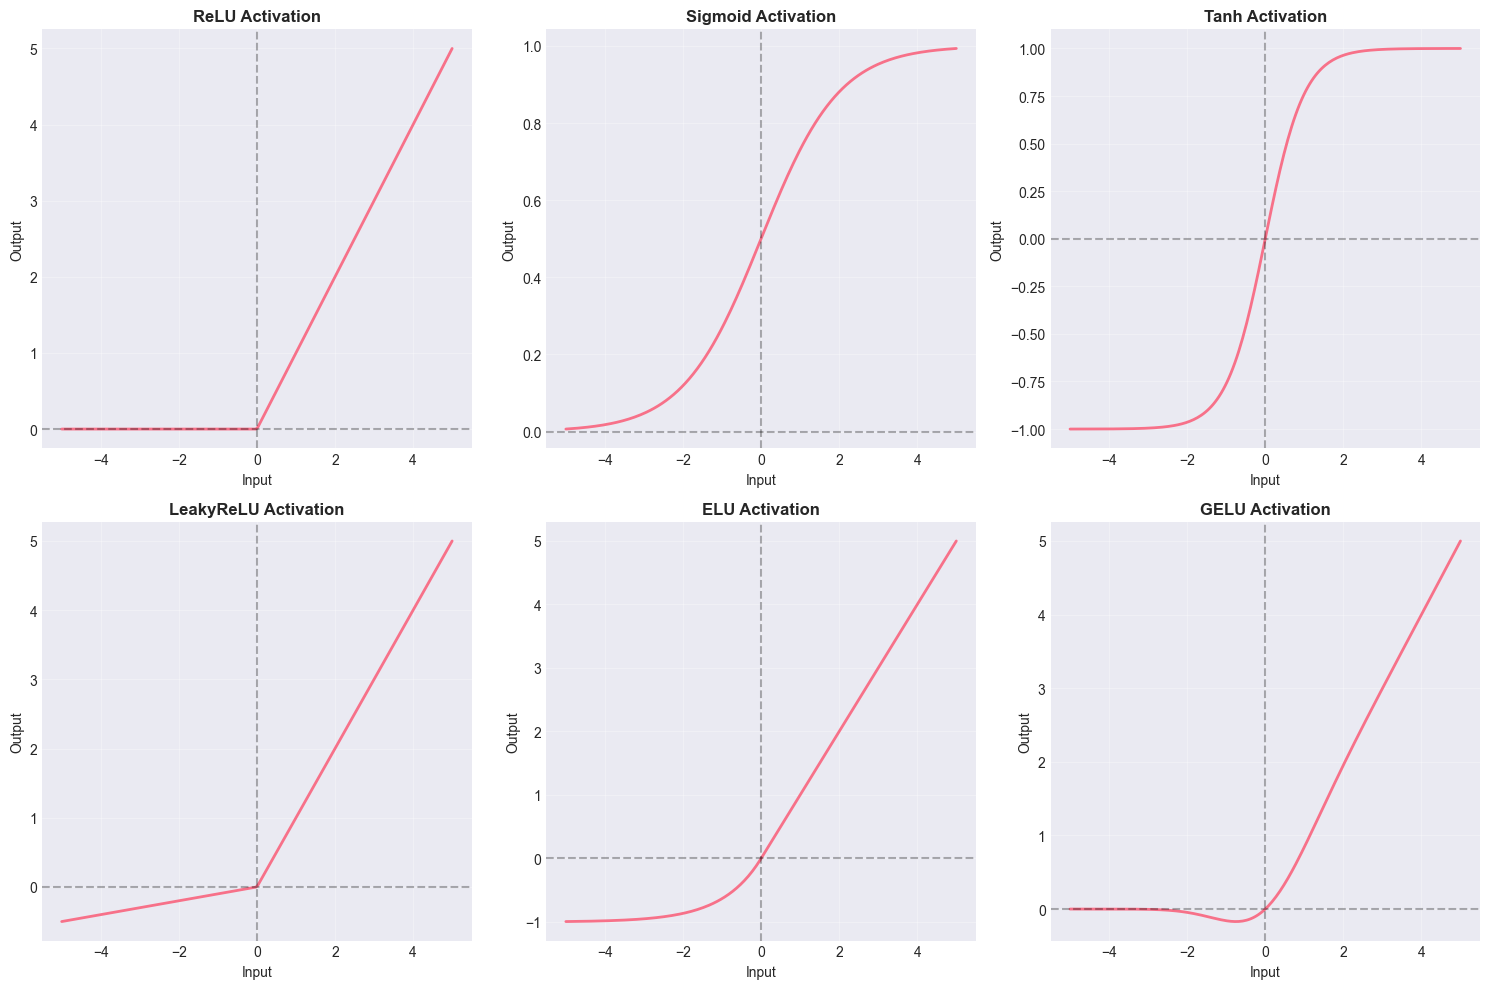

In [2]:
# Create input range
x = torch.linspace(-5, 5, 200)

# Define activation functions
activations = {
    'ReLU': F.relu(x),
    'Sigmoid': torch.sigmoid(x),
    'Tanh': torch.tanh(x),
    'LeakyReLU': F.leaky_relu(x, 0.1),
    'ELU': F.elu(x),
    'GELU': F.gelu(x)
}

# Plot all activation functions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, (name, activation) in enumerate(activations.items()):
    axes[idx].plot(x.numpy(), activation.numpy(), linewidth=2)
    axes[idx].set_title(f'{name} Activation', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Input')
    axes[idx].set_ylabel('Output')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].axhline(y=0, color='k', linestyle='--', alpha=0.3)
    axes[idx].axvline(x=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Key Properties of Activation Functions:

- **ReLU**: Simple, fast, helps with vanishing gradient. Can have "dying ReLU" problem.
- **Sigmoid**: Outputs in (0,1), useful for probabilities. Suffers from vanishing gradients.
- **Tanh**: Outputs in (-1,1), zero-centered. Still has vanishing gradient issues.
- **LeakyReLU**: Fixes dying ReLU by allowing small negative values.
- **ELU**: Smooth, can produce negative outputs, helps with learning.
- **GELU**: Used in transformers, smooth approximation of ReLU.

## 2. Building Deeper Networks

Let's create a deeper network and compare it with a shallow one.

In [3]:
class ShallowNetwork(nn.Module):
    """A simple 2-layer network"""
    def __init__(self, input_size, hidden_size, output_size):
        super(ShallowNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class DeepNetwork(nn.Module):
    """A deeper 5-layer network"""
    def __init__(self, input_size, hidden_size, output_size):
        super(DeepNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc5 = nn.Linear(hidden_size // 2, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = self.fc5(x)
        return x

# Create instances
shallow_model = ShallowNetwork(20, 64, 10).to(device)
deep_model = DeepNetwork(20, 64, 10).to(device)

print("Shallow Network:")
print(shallow_model)
print(f"Parameters: {sum(p.numel() for p in shallow_model.parameters()):,}\n")

print("Deep Network:")
print(deep_model)
print(f"Parameters: {sum(p.numel() for p in deep_model.parameters()):,}")

Shallow Network:
ShallowNetwork(
  (fc1): Linear(in_features=20, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)
Parameters: 1,994

Deep Network:
DeepNetwork(
  (fc1): Linear(in_features=20, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=64, bias=True)
  (fc4): Linear(in_features=64, out_features=32, bias=True)
  (fc5): Linear(in_features=32, out_features=10, bias=True)
)
Parameters: 12,074


## 3. Regularization Techniques

Regularization helps prevent overfitting. Let's explore Dropout and Batch Normalization.

In [4]:
class RegularizedNetwork(nn.Module):
    """Network with Dropout and Batch Normalization"""
    def __init__(self, input_size, hidden_size, output_size, dropout_rate=0.3):
        super(RegularizedNetwork, self).__init__()

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.bn2 = nn.BatchNorm1d(hidden_size)
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        return x

regularized_model = RegularizedNetwork(20, 128, 10).to(device)
print("Regularized Network with Dropout and BatchNorm:")
print(regularized_model)
print(f"\nParameters: {sum(p.numel() for p in regularized_model.parameters()):,}")

Regularized Network with Dropout and BatchNorm:
RegularizedNetwork(
  (fc1): Linear(in_features=20, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)

Parameters: 21,002


### Understanding Dropout

Dropout randomly sets a fraction of input units to 0 during training, which helps prevent overfitting.

In [5]:
# Demonstrate dropout
x = torch.ones(1, 10)
dropout = nn.Dropout(p=0.5)

print("Original tensor:")
print(x)

print("\nWith dropout (training mode):")
dropout.train()
print(dropout(x))
print(dropout(x))  # Different each time

print("\nWith dropout (eval mode):")
dropout.eval()
print(dropout(x))  # No dropout in eval mode

Original tensor:
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])

With dropout (training mode):
tensor([[0., 0., 2., 2., 2., 0., 0., 0., 0., 0.]])
tensor([[2., 2., 2., 0., 0., 2., 0., 2., 2., 0.]])

With dropout (eval mode):
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])


## 4. Weight Initialization

Proper weight initialization is crucial for training deep networks.

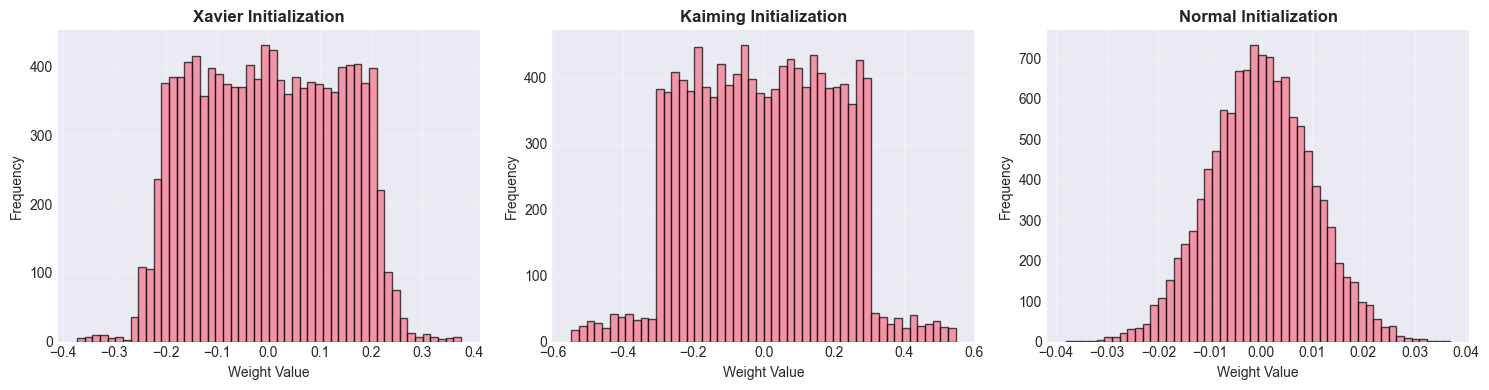

Xavier: Good for sigmoid/tanh activations
Kaiming: Designed for ReLU activations
Normal: Simple but less optimized


In [6]:
def initialize_weights(model, init_type='xavier'):
    """Initialize network weights"""
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if init_type == 'xavier':
                nn.init.xavier_uniform_(m.weight)
            elif init_type == 'kaiming':
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
            elif init_type == 'normal':
                nn.init.normal_(m.weight, mean=0, std=0.01)

            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

# Compare different initializations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
init_types = ['xavier', 'kaiming', 'normal']

for idx, init_type in enumerate(init_types):
    model = DeepNetwork(20, 64, 10).to(device)
    initialize_weights(model, init_type)

    # Collect all weights
    weights = []
    for param in model.parameters():
        if len(param.shape) > 1:  # Only weight matrices
            weights.extend(param.detach().cpu().numpy().flatten())

    axes[idx].hist(weights, bins=50, alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{init_type.capitalize()} Initialization', fontweight='bold')
    axes[idx].set_xlabel('Weight Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Xavier: Good for sigmoid/tanh activations")
print("Kaiming: Designed for ReLU activations")
print("Normal: Simple but less optimized")

## 5. Training and Comparing Networks

Let's train networks with and without regularization on a realistic task.

In [8]:
# Generate a more complex dataset
def generate_data(n_samples=2000, n_features=20, n_classes=10):
    """Generate synthetic classification data"""
    X = torch.randn(n_samples, n_features)
    # Create non-linear relationships
    y = (X[:, 0] + X[:, 1]**2 + X[:, 2] * X[:, 3]).long() % n_classes # y = (x0+x1^2+x2*x3) mod n_classes
    return X, y

# Create train and test sets
X_train, y_train = generate_data(1600)
X_test, y_test = generate_data(400)

# Create data loaders
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Features: {X_train.shape[1]}")
print(f"Classes: {len(torch.unique(y_train))}")

Training samples: 1600
Test samples: 400
Features: 20
Classes: 10


In [9]:
def train_model(model, train_loader, test_loader, epochs=50, lr=0.001):
    """Train and evaluate a model"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += batch_y.size(0)
            train_correct += predicted.eq(batch_y).sum().item()

        train_losses.append(train_loss / len(train_loader))
        train_accs.append(100. * train_correct / train_total)

        # Testing
        model.eval()
        test_loss = 0
        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)

                test_loss += loss.item()
                _, predicted = outputs.max(1)
                test_total += batch_y.size(0)
                test_correct += predicted.eq(batch_y).sum().item()

        test_losses.append(test_loss / len(test_loader))
        test_accs.append(100. * test_correct / test_total)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}: "
                  f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.2f}% | "
                  f"Test Loss: {test_losses[-1]:.4f}, Test Acc: {test_accs[-1]:.2f}%")

    return train_losses, test_losses, train_accs, test_accs

In [10]:
# Train both models
print("Training Deep Network without regularization...")
deep_model = DeepNetwork(20, 64, 10).to(device)
initialize_weights(deep_model, 'kaiming')
deep_train_loss, deep_test_loss, deep_train_acc, deep_test_acc = train_model(
    deep_model, train_loader, test_loader, epochs=50
)

print("\nTraining Regularized Network...")
reg_model = RegularizedNetwork(20, 64, 10, dropout_rate=0.3).to(device)
initialize_weights(reg_model, 'kaiming')
reg_train_loss, reg_test_loss, reg_train_acc, reg_test_acc = train_model(
    reg_model, train_loader, test_loader, epochs=50
)

Training Deep Network without regularization...
Epoch 10/50: Train Loss: 1.1077, Train Acc: 62.62% | Test Loss: 1.7184, Test Acc: 44.25%
Epoch 20/50: Train Loss: 0.3954, Train Acc: 89.19% | Test Loss: 2.1271, Test Acc: 45.00%
Epoch 30/50: Train Loss: 0.0940, Train Acc: 99.38% | Test Loss: 2.8982, Test Acc: 43.25%
Epoch 40/50: Train Loss: 0.0241, Train Acc: 100.00% | Test Loss: 3.5829, Test Acc: 43.75%
Epoch 50/50: Train Loss: 0.0092, Train Acc: 100.00% | Test Loss: 4.0844, Test Acc: 44.25%

Training Regularized Network...
Epoch 10/50: Train Loss: 1.6811, Train Acc: 43.25% | Test Loss: 1.5838, Test Acc: 45.50%
Epoch 20/50: Train Loss: 1.5283, Train Acc: 46.75% | Test Loss: 1.4762, Test Acc: 48.25%
Epoch 30/50: Train Loss: 1.3923, Train Acc: 48.50% | Test Loss: 1.3666, Test Acc: 49.75%
Epoch 40/50: Train Loss: 1.3353, Train Acc: 52.25% | Test Loss: 1.2629, Test Acc: 54.00%
Epoch 50/50: Train Loss: 1.2467, Train Acc: 53.75% | Test Loss: 1.1757, Test Acc: 54.25%


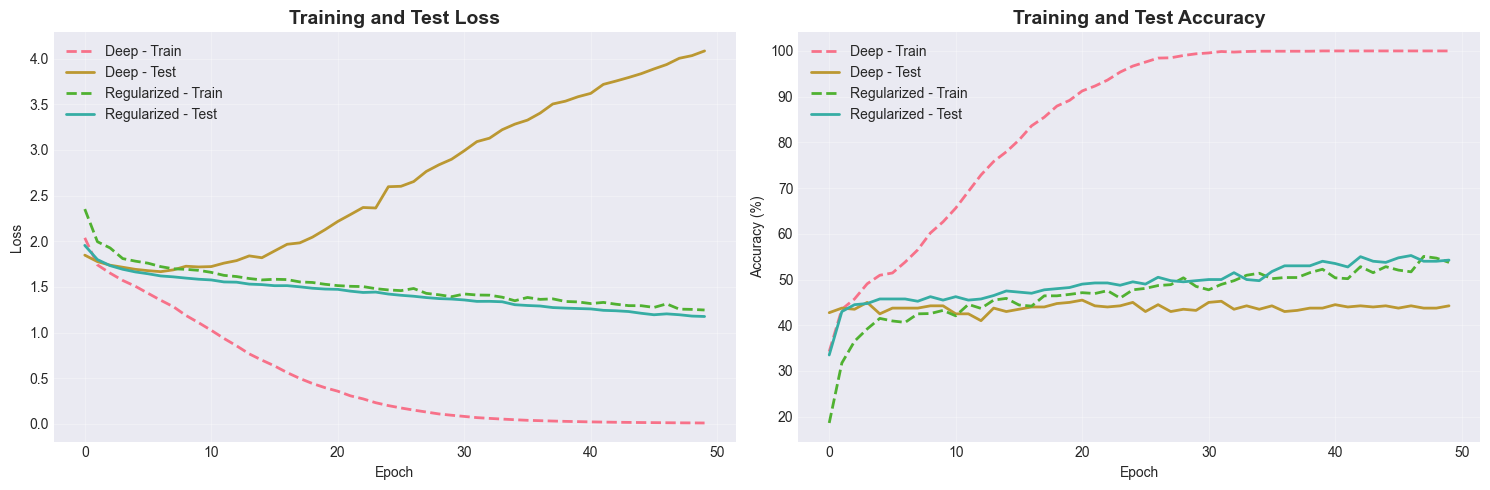


📊 Final Results:
Deep Network - Test Accuracy: 44.25%
Regularized Network - Test Accuracy: 54.25%


In [11]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(deep_train_loss, label='Deep - Train', linestyle='--', linewidth=2)
axes[0].plot(deep_test_loss, label='Deep - Test', linewidth=2)
axes[0].plot(reg_train_loss, label='Regularized - Train', linestyle='--', linewidth=2)
axes[0].plot(reg_test_loss, label='Regularized - Test', linewidth=2)
axes[0].set_title('Training and Test Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(deep_train_acc, label='Deep - Train', linestyle='--', linewidth=2)
axes[1].plot(deep_test_acc, label='Deep - Test', linewidth=2)
axes[1].plot(reg_train_acc, label='Regularized - Train', linestyle='--', linewidth=2)
axes[1].plot(reg_test_acc, label='Regularized - Test', linewidth=2)
axes[1].set_title('Training and Test Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Final Results:")
print(f"Deep Network - Test Accuracy: {deep_test_acc[-1]:.2f}%")
print(f"Regularized Network - Test Accuracy: {reg_test_acc[-1]:.2f}%")

## 6. Gradient Flow Visualization

Understanding how gradients flow through the network is important for debugging.

### What is Gradient Flow?

**Gradient flow** refers to how gradients propagate backward through the network layers during backpropagation.

Remember the training process:
1. **Forward pass**: Data flows through layers → produces predictions
2. **Loss calculation**: Compare predictions to actual labels
3. **Backward pass**: Gradients flow backward through layers → tells each weight how to update

### Why Does It Matter?

**Healthy gradient flow** means:
- ✅ All layers receive meaningful gradients
- ✅ Weights update appropriately
- ✅ Network learns effectively

**Poor gradient flow** causes problems:
- ❌ **Vanishing gradients**: Gradients become too small in early layers → those layers don't learn
- ❌ **Exploding gradients**: Gradients become too large → training becomes unstable
- ❌ **Dead neurons**: Some neurons stop learning entirely

### The Visualization Below Shows:

- **Average gradient**: Typical gradient magnitude for each layer's weights
- **Max gradient**: Largest gradient in each layer

**What to look for:**
- Gradients should be **similar across layers** (not too different in magnitude)
- Very small gradients (< 0.001) suggest vanishing gradient problem
- Very large gradients (> 10) suggest exploding gradient problem
- Gradients near zero in early layers mean those layers aren't learning

This helps diagnose why a network might not be training well!

Analyzing gradient flow through the deep network...


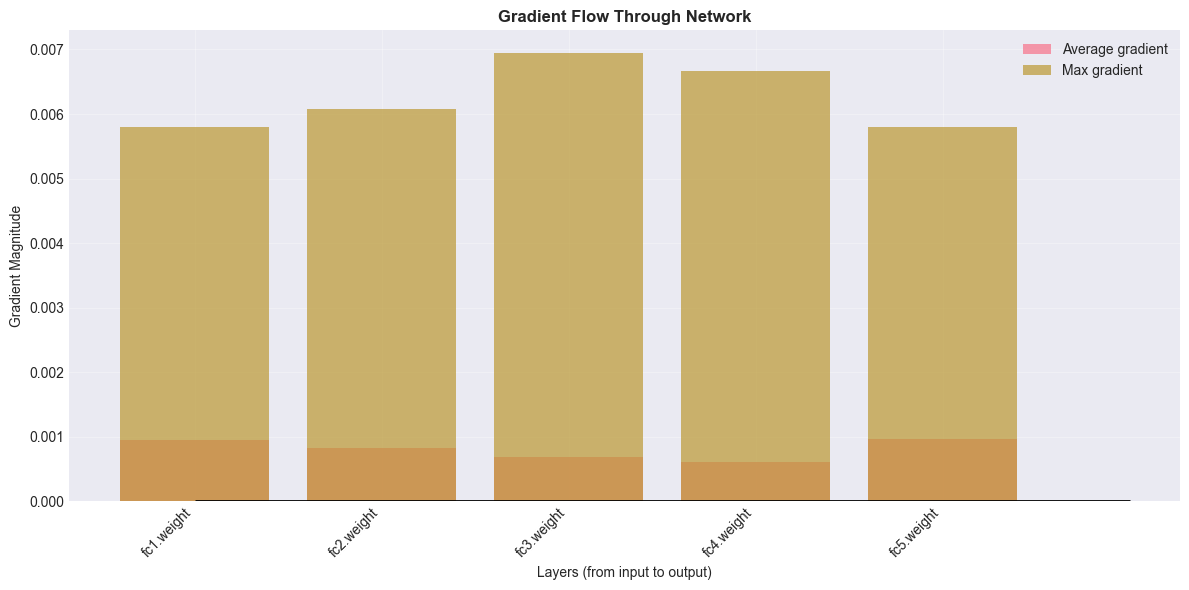


📊 Gradient Analysis:
Smallest average gradient: 0.000604 (layer: fc4.weight)
Largest average gradient: 0.000965 (layer: fc5.weight)
Gradient ratio (largest/smallest): 1.60x
✓ Gradient flow looks healthy!


In [ ]:
def plot_gradient_flow(model, X, y):
    """Visualize gradient magnitudes across layers"""
    model.train()
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()

    # Do one forward and backward pass
    optimizer.zero_grad()
    outputs = model(X.to(device))
    loss = criterion(outputs, y.to(device))
    loss.backward()  # This computes gradients for all weights

    # Collect gradients from each layer
    ave_grads = []  # Average gradient magnitude per layer
    max_grads = []  # Maximum gradient magnitude per layer
    layers = []     # Layer names

    for name, param in model.named_parameters():
        if param.requires_grad and "weight" in name:
            layers.append(name)
            # Calculate average magnitude of gradients in this layer
            ave_grads.append(param.grad.abs().mean().cpu().item())
            # Find the maximum gradient in this layer
            max_grads.append(param.grad.abs().max().cpu().item())

    # Plot the results
    plt.figure(figsize=(12, 6))
    plt.bar(np.arange(len(ave_grads)), ave_grads, alpha=0.7, label='Average gradient')
    plt.bar(np.arange(len(max_grads)), max_grads, alpha=0.7, label='Max gradient')
    plt.hlines(0, 0, len(ave_grads), lw=2, color="k")
    plt.xticks(range(len(ave_grads)), layers, rotation=45, ha='right')
    plt.xlabel("Layers (from input to output)")
    plt.ylabel("Gradient Magnitude")
    plt.title("Gradient Flow Through Network", fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\n📊 Gradient Analysis:")
    print(f"Smallest average gradient: {min(ave_grads):.6f} (layer: {layers[ave_grads.index(min(ave_grads))]})")
    print(f"Largest average gradient: {max(ave_grads):.6f} (layer: {layers[ave_grads.index(max(ave_grads))]})")
    print(f"Gradient ratio (largest/smallest): {max(ave_grads)/min(ave_grads):.2f}x")

    if max(ave_grads)/min(ave_grads) > 100:
        print("⚠️  Large gradient ratio detected - may indicate gradient flow issues")
    else:
        print("✓ Gradient flow looks healthy!")

# Visualize gradient flow
print("Analyzing gradient flow through the deep network...")
sample_X, sample_y = next(iter(train_loader))
plot_gradient_flow(deep_model, sample_X, sample_y)

## 🎯 Key Takeaways

You've learned:
- ✅ Different activation functions and when to use them
- ✅ How to build deeper networks
- ✅ Regularization techniques (Dropout, BatchNorm)
- ✅ Weight initialization strategies
- ✅ How to analyze gradient flow

### Next Steps

Now that you understand neural networks deeply, you're ready to learn about:
1. **Autoencoders** - Networks that learn to compress and reconstruct data
2. **Encoder-Decoder architectures** - The foundation for VAEs

Continue to notebook 03! 🚀